# Light-curve classification with Astromer2

Classifies [Roman Open Universe hourglass simulation](https://zenodo.org/records/14262943)
transients (top-5 classes, 10 % stratified sample) using ATCAT multiband embeddings
and a linear Ridge classifier with 5-fold cross-validation.

The pipeline is split into four independent steps with intermediate results cached as
Parquet files, so each step can be re-run without repeating the expensive embedding.

## Step 1 — Download and sample

Download the Hourglass objects and photometry tables from Zenodo, keep the five most
common transient classes, draw a 10 % stratified sample per class, and save the joined
nested-pandas frame as a Parquet file for later use.

In [1]:
import os
import tempfile
import urllib.request

import nested_pandas as npd
import pandas as pd

ZENODO = "https://zenodo.org/records/14262943/files"
CACHE = os.path.join(tempfile.gettempdir(), "hourglass_zenodo")
SAMPLE_PATH = os.path.join(CACHE, "roman_sample.parquet")
os.makedirs(CACHE, exist_ok=True)

for fname in ("hourglass_objects.parquet", "hourglass_photometry.parquet"):
    dest = os.path.join(CACHE, fname)
    if not os.path.exists(dest):
        print(f"Downloading {fname}\u2026")
        urllib.request.urlretrieve(f"{ZENODO}/{fname}?download=1", dest)

objects = npd.read_parquet(os.path.join(CACHE, "hourglass_objects.parquet"))
top5 = objects["class"].value_counts().head(5).index.tolist()
print(f"Top-5 classes: {top5}")

sample = (
    objects[objects["class"].isin(top5)]
    .groupby("class")
    .sample(frac=0.10, random_state=42)
)
print(f"Sample: {len(sample):,} objects")
print(sample["class"].value_counts().to_string())

photometry = pd.read_parquet(os.path.join(CACHE, "hourglass_photometry.parquet"))
nf = npd.NestedFrame(sample).add_nested(photometry, name="lc", on="cid")
nf.to_parquet(SAMPLE_PATH)
print(f"\nSaved {len(nf):,} objects with nested light curves \u2192 {SAMPLE_PATH}")

Top-5 classes: ['CCSN', 'SN_Ia', 'SN_Iax', 'SNIa-91bg', 'Fixed_mag']
Sample: 6,404 objects
class
CCSN         3918
SN_Ia        2173
SNIa-91bg     132
SN_Iax        132
Fixed_mag      49


/tmp/ipykernel_66595/3417312126.py:32: DeprecationWarning: Call to deprecated method add_nested. (`add_nested` will be removed in version 0.7.0, use `join_nested` instead.) -- Deprecated since version 0.6.0.
  nf = npd.NestedFrame(sample).add_nested(photometry, name="lc", on="cid")



Saved 6,404 objects with nested light curves → /tmp/hourglass_zenodo/roman_sample.parquet


## Step 2 — Embed with ATCAT

Load the sample, run ATCAT (a multiband causal transformer trained on LSST-like light curves)
across four Roman bands (R, Z, Y, J) mapped to LSST band indices 1–4.
ATCAT takes fluxes (`fluxcal`, ZP=27.5) and produces a single 384-dim embedding per object.

> **This cell takes ~20 minutes on a modern CPU.**  Re-running it is only necessary if
> the sample or model changes; the embeddings Parquet is cached afterwards.


In [2]:
import os
import tempfile

import nested_pandas as npd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq

from light_curve.embed import ATCAT

CACHE = os.path.join(tempfile.gettempdir(), "hourglass_zenodo")
SAMPLE_PATH = os.path.join(CACHE, "roman_sample.parquet")
EMBED_PATH  = os.path.join(CACHE, "roman_embeddings.parquet")

# Roman bands mapped to the nearest LSST band indices (0=u 1=g 2=r 3=i 4=z 5=Y)
BAND_GROUPS = {"R": 1, "Z": 2, "Y": 3, "J": 4}
EMBED_DIM = 384  # ATCAT embedding dimension (single band group)
TOTAL_DIM = EMBED_DIM

if os.path.exists(EMBED_PATH):
    size_mb = os.path.getsize(EMBED_PATH) / 1e6
    print(f"Embeddings already cached ({size_mb:.1f} MB) \u2192 {EMBED_PATH}")
else:
    nf = npd.read_parquet(SAMPLE_PATH)

    # fluxcal is calibrated to AB ZP=27.5 (SNANA/ELAsTiCC convention).
    # mag_zp=26.0 rescales the fluxes up (~4×), placing Roman flux levels
    # closer to the LSST training distribution of ATCAT.
    model = ATCAT.from_hf(output="mean", band_groups=BAND_GROUPS, mag_zp=26.0)
    print(f"ATCAT loaded (embed_dim={EMBED_DIM}, seq_size={model.seq_size})")

    VALID_BANDS = set(BAND_GROUPS.keys())

    def embed_row(row):
        mjd      = np.asarray(row["lc.mjd"],          dtype=np.float64)
        flux     = np.asarray(row["lc.fluxcal"],       dtype=np.float64)
        flux_err = np.asarray(row["lc.fluxcal_err"],   dtype=np.float64)
        band     = np.asarray(row["lc.band"])
        flag     = np.asarray(row["lc.phot_flag"])

        ok = (flag == 0) & np.isin(band, list(VALID_BANDS))
        mjd, flux, flux_err, band = mjd[ok], flux[ok], flux_err[ok], band[ok]

        if any((band == b).sum() == 0 for b in VALID_BANDS):
            return {"embedding": np.zeros(TOTAL_DIM, dtype=np.float32)}

        emb = model(mjd, flux, flux_err, band=band)  # (1, 1, 1, 384)
        return {"embedding": emb.reshape(-1).astype(np.float32)}

    print("Embedding light curves\u2026")
    nf = nf.map_rows(
        embed_row,
        columns=["lc.mjd", "lc.fluxcal", "lc.fluxcal_err", "lc.band", "lc.phot_flag"],
        append_columns=True,
    )
    print("Done.")

    X = np.vstack(nf["embedding"].to_numpy())  # (N, 384) float32
    table = pa.table({
        "cid":       pa.array(nf["cid"].to_numpy()),
        "class":     pa.array(nf["class"].to_numpy().astype(str)),
        "embedding": pa.FixedSizeListArray.from_arrays(
                         pa.array(X.ravel(), type=pa.float32()), TOTAL_DIM
                     ),
    })
    pq.write_table(table, EMBED_PATH)
    size_mb = os.path.getsize(EMBED_PATH) / 1e6
    print(f"Saved {len(table):,} embeddings ({size_mb:.1f} MB) \u2192 {EMBED_PATH}")


/workdir/light-curve-python/light-curve/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-24 17:19:51.441416372 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card1": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card1/device/vendor"


2026-05-24 17:19:51.441484620 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"
/workdir/light-curve-python/light-curve/light_curve/embed/model.py:60: ExperimentalWarning: light_curve.embed.atcat.ATCAT is experimental and may change in future versions
  warn_experimental(


ATCAT loaded (embed_dim=384, seq_size=243)
Embedding light curves…


Done.
Saved 6,404 embeddings (6.3 MB) → /tmp/hourglass_zenodo/roman_embeddings.parquet


## Step 3 — 5-fold classification

Load the embeddings, fit a Ridge classifier with `StratifiedKFold(k=5)`, collect
out-of-fold predictions, and save them together with class labels as a Parquet file.

In [3]:
import json
import os
import tempfile

import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

CACHE     = os.path.join(tempfile.gettempdir(), "hourglass_zenodo")
EMBED_PATH = os.path.join(CACHE, "roman_embeddings.parquet")
OOF_PATH   = os.path.join(CACHE, "roman_oof.parquet")

table = pq.read_table(EMBED_PATH)
X = np.array(table["embedding"].to_pylist(), dtype=np.float64)  # cast fp32 → fp64 to avoid ill-conditioned Ridge

le = LabelEncoder()
y = le.fit_transform(table["class"].to_pylist())
class_names = list(le.classes_)
print(f"Classes: {class_names}")

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_pred = np.empty(len(y), dtype=int)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X[train_idx])
    X_val = scaler.transform(X[val_idx])
    clf = RidgeClassifier(alpha=0.001)
    clf.fit(X_tr, y[train_idx])
    oof_pred[val_idx] = clf.predict(X_val)
    fold_f1 = f1_score(y[val_idx], oof_pred[val_idx], average="macro", zero_division=0)
    print(f"  Fold {fold + 1}/5  macro F1 = {fold_f1:.4f}")

macro_f1 = f1_score(y, oof_pred, average="macro", zero_division=0)
print(f"\nOOF macro F1: {macro_f1:.4f}")
print("\nClassification report (5-fold OOF):")
print(classification_report(y, oof_pred, target_names=class_names, zero_division=0))

# Store class_names in parquet metadata so Step 4 doesn't need a separate file
oof_table = pa.table({"cid": table["cid"], "y_true": y.tolist(), "y_pred": oof_pred.tolist()})
oof_table = oof_table.replace_schema_metadata({"class_names": json.dumps(class_names)})
pq.write_table(oof_table, OOF_PATH)
print(f"OOF predictions saved \u2192 {OOF_PATH}")

assert macro_f1 > 0.45, f"Expected macro F1 > 0.45, got {macro_f1:.4f}"

Classes: [np.str_('CCSN'), np.str_('Fixed_mag'), np.str_('SNIa-91bg'), np.str_('SN_Ia'), np.str_('SN_Iax')]


  Fold 1/5  macro F1 = 0.5408


  Fold 2/5  macro F1 = 0.5636


  Fold 3/5  macro F1 = 0.5604


  Fold 4/5  macro F1 = 0.6161


  Fold 5/5  macro F1 = 0.5828

OOF macro F1: 0.5755

Classification report (5-fold OOF):
              precision    recall  f1-score   support

        CCSN       0.71      0.99      0.82      3918
   Fixed_mag       1.00      0.86      0.92        49
   SNIa-91bg       0.82      0.28      0.42       132
       SN_Ia       0.93      0.36      0.52      2173
      SN_Iax       0.71      0.11      0.20       132

    accuracy                           0.74      6404
   macro avg       0.83      0.52      0.58      6404
weighted avg       0.79      0.74      0.70      6404

OOF predictions saved → /tmp/hourglass_zenodo/roman_oof.parquet


## Step 4 — Metrics and plots

Load the OOF predictions and visualise the confusion matrix normalised by **purity**
(column-normalised): each column sums to 100 %, and the diagonal entry equals precision.
Classes are ordered from most similar (Ia subtypes) to least (Fixed_mag).

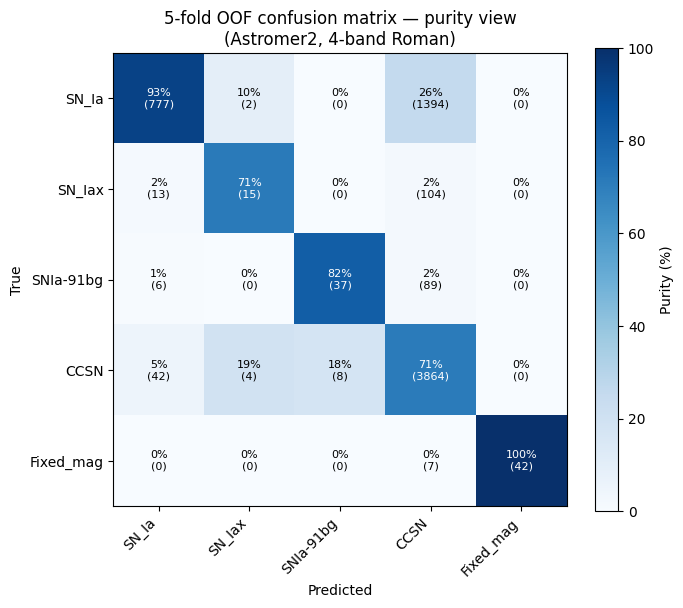

In [4]:
import json
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
from sklearn.metrics import confusion_matrix

CACHE    = os.path.join(tempfile.gettempdir(), "hourglass_zenodo")
OOF_PATH = os.path.join(CACHE, "roman_oof.parquet")

table = pq.read_table(OOF_PATH)
class_names = json.loads(table.schema.metadata[b"class_names"])
y        = np.array(table["y_true"].to_pylist())
oof_pred = np.array(table["y_pred"].to_pylist())

cm = confusion_matrix(y, oof_pred)

ORDER = ["SN_Ia", "SN_Iax", "SNIa-91bg", "CCSN", "Fixed_mag"]
idx = [class_names.index(c) for c in ORDER]
cm = cm[np.ix_(idx, idx)]

col_sums = cm.sum(axis=0, keepdims=True)
cm_purity = np.where(col_sums > 0, cm / col_sums * 100, 0.0)

labels = np.array([
    [f"{p:.0f}%\n({n})" for p, n in zip(row_p, row_n)]
    for row_p, row_n in zip(cm_purity, cm)
])

n = len(ORDER)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_purity, cmap="Blues", vmin=0, vmax=100)
fig.colorbar(im, ax=ax).set_label("Purity (%)")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(ORDER, rotation=45, ha="right")
ax.set_yticklabels(ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(n):
    for j in range(n):
        ax.text(j, i, labels[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm_purity[i, j] > 55 else "black")
ax.set_title("5-fold OOF confusion matrix \u2014 purity view\n(Astromer2, 4-band Roman)")
plt.tight_layout()
plt.show()

Each column shows the **purity** of a predicted class: the fraction of objects classified
as that class which truly belong to it.  The diagonal entry equals precision; off-diagonal
entries are contamination from other classes.

The Ia subtypes (SN_Ia, SN_Iax, SNIa-91bg) are the hardest to separate — they share
similar rise times and peak luminosities.  CCSN and Fixed_mag are well-isolated.

## Notes

- `reduction="beginning"` mirrors the original pipeline: each band is truncated at the
  first 200 observations.  Switching to `"non-overlapping-windows"` (the default) would
  average embeddings over all windows and may improve accuracy on well-sampled light curves.
- Astromer2 is pretrained on MACHO R-band light curves, so Roman Z/Y/J bands are
  out-of-distribution — replacing it with a Roman-specific model would raise accuracy.
- See the [similarity search tutorial](similarity_search.ipynb) for the cosine-distance
  nearest-neighbour approach on ZTF data.